In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data sorce: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Let's try to predict the risk of stroke given the features.

In [5]:
df = pd.read_csv("dataset/healthcare-dataset-stroke-data.csv")
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [8]:
from PrepareDatapy import DataProcessor
processor = DataProcessor(name="stroke")

In [61]:
categorical_cols = ['gender', 'smoking_status','work_type', 'Residence_type']
binary_cols = ['ever_married']
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
id_cols = ['id']
target_col = 'stroke'

processed_data = processor.process_dataset(
    df=df,
    categorical_cols=categorical_cols,
    binary_cols=binary_cols,
    numerical_cols=numerical_cols,
    target_col=target_col,
    id_cols=id_cols,
    scale_numerical=True,
    handle_missing='impute'
)

Creating embedding for column: gender
Creating embedding for column: smoking_status
Creating embedding for column: work_type
Creating embedding for column: Residence_type


In [63]:
processed_data.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,smoking_status_label,work_type_label,stroke
0,1,1.051434,0,1,0,1.000000e+00,1,2.706375,1.005086,8.881784e-16,1,2,1
1,0,0.786070,0,0,0,1.623400e-17,0,2.121559,-0.098981,1.000000e+00,2,3,1
2,1,1.626390,0,1,0,1.000000e+00,0,-0.005028,0.472536,1.000000e+00,2,2,1
3,0,0.255342,0,0,0,1.000000e+00,1,1.437358,0.719327,-2.280418e-17,3,2,1
4,0,1.582163,1,0,0,1.623400e-17,0,1.501184,-0.631531,1.000000e+00,2,3,1


Now we have processed the data, we will build a simple NN using pytorch.

In [66]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [68]:
X = processed_data.drop('stroke', axis=1).values
y = processed_data['stroke'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

In [72]:
from NN_model import NeuralPredictor

In [74]:
input_size = X_train.shape[1]
predictor = NeuralPredictor(input_size=input_size, hidden_layers=[64, 32])

Epoch 10/100, Train Loss: 0.1475, Train Acc: 0.9543, Test Loss: 0.1850, Test Acc: 0.9393
Epoch 20/100, Train Loss: 0.1443, Train Acc: 0.9543, Test Loss: 0.1834, Test Acc: 0.9393
Epoch 30/100, Train Loss: 0.1378, Train Acc: 0.9547, Test Loss: 0.1894, Test Acc: 0.9393
Epoch 40/100, Train Loss: 0.1404, Train Acc: 0.9550, Test Loss: 0.1911, Test Acc: 0.9403
Epoch 50/100, Train Loss: 0.1351, Train Acc: 0.9555, Test Loss: 0.2003, Test Acc: 0.9384
Epoch 60/100, Train Loss: 0.1329, Train Acc: 0.9557, Test Loss: 0.2084, Test Acc: 0.9393
Epoch 70/100, Train Loss: 0.1276, Train Acc: 0.9565, Test Loss: 0.2070, Test Acc: 0.9374
Epoch 80/100, Train Loss: 0.1293, Train Acc: 0.9574, Test Loss: 0.2041, Test Acc: 0.9364
Epoch 90/100, Train Loss: 0.1246, Train Acc: 0.9565, Test Loss: 0.2200, Test Acc: 0.9364
Epoch 100/100, Train Loss: 0.1203, Train Acc: 0.9591, Test Loss: 0.2183, Test Acc: 0.9354


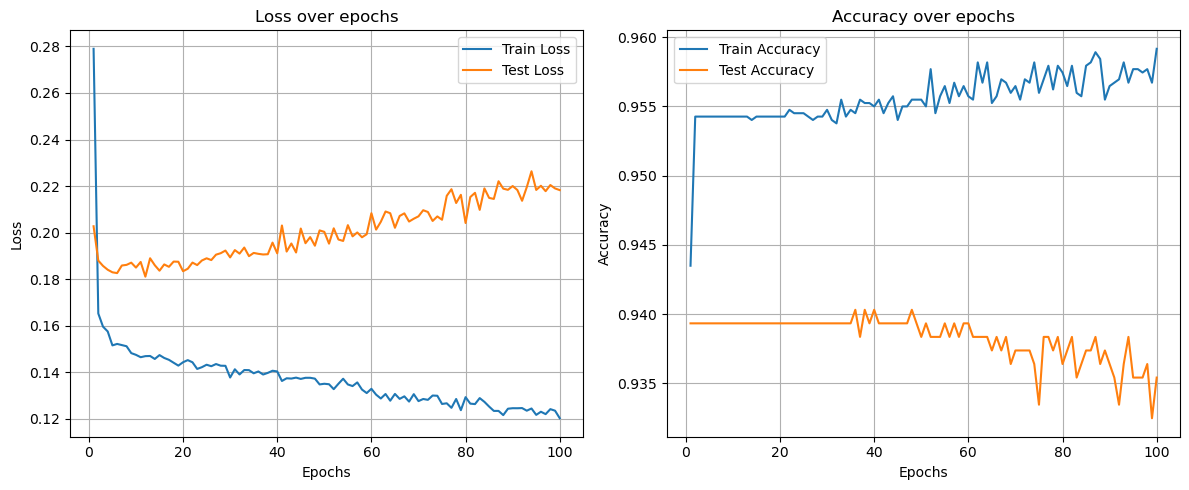

Final Test Accuracy: 0.9354


In [76]:
history = predictor.train(train_loader, test_loader, num_epochs=100)
test_loss, test_accuracy = predictor.evaluate(test_loader)
print(f'Final Test Accuracy: {test_accuracy:.4f}')

In [78]:
from logistic_regressor import LogisticRegressor

Epoch 10/100, Train Loss: 0.1898, Train Acc: 0.9533, Test Loss: 0.2219, Test Acc: 0.9344
Epoch 20/100, Train Loss: 0.1813, Train Acc: 0.9525, Test Loss: 0.2108, Test Acc: 0.9344
Epoch 30/100, Train Loss: 0.1745, Train Acc: 0.9530, Test Loss: 0.2042, Test Acc: 0.9374
Epoch 40/100, Train Loss: 0.1707, Train Acc: 0.9535, Test Loss: 0.1996, Test Acc: 0.9384
Epoch 50/100, Train Loss: 0.1679, Train Acc: 0.9538, Test Loss: 0.1965, Test Acc: 0.9384
Epoch 60/100, Train Loss: 0.1655, Train Acc: 0.9540, Test Loss: 0.1940, Test Acc: 0.9384
Epoch 70/100, Train Loss: 0.1636, Train Acc: 0.9540, Test Loss: 0.1920, Test Acc: 0.9393
Epoch 80/100, Train Loss: 0.1629, Train Acc: 0.9543, Test Loss: 0.1902, Test Acc: 0.9393
Epoch 90/100, Train Loss: 0.1607, Train Acc: 0.9543, Test Loss: 0.1891, Test Acc: 0.9393
Epoch 100/100, Train Loss: 0.1601, Train Acc: 0.9543, Test Loss: 0.1879, Test Acc: 0.9393


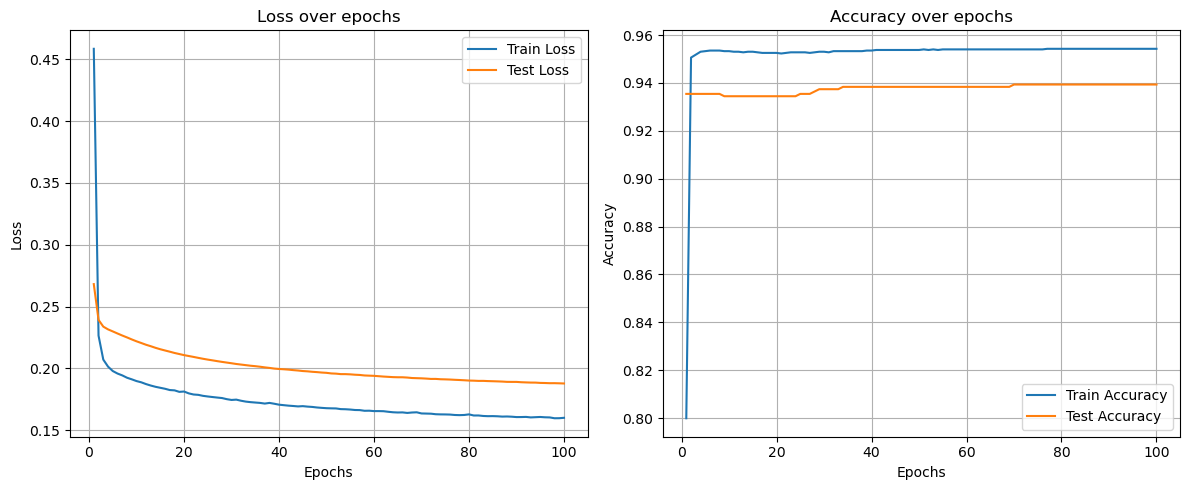

In [79]:
model = LogisticRegressor(input_size=input_size)
history = model.train(train_loader, test_loader, num_epochs=100, print_every=10)